In [1]:
import os
import sys

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
# Notebook is inside: inverse-source-em/notebooks/
# Project root is one level above
project_root = os.path.abspath("..")

# Add src/ to Python path
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

# Models and data paths
models_path = os.path.join(project_root, "models")
data_path = os.path.join(project_root, "data", "classification", "dataset_classification.npz")

# ------------------------------------------------------------
# Libraries
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------
plt.style.use("default")
plt.rcParams["grid.color"] = "white"
plt.rcParams["grid.alpha"] = 0.15
plt.rcParams["grid.linewidth"] = 0.6

# ------------------------------------------------------------
# Torch settings
# ------------------------------------------------------------
torch.set_default_dtype(torch.float64)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
print("Project root:", project_root)
print("Src path:", src_path)
print("Models path:", models_path)
print("Data path:", data_path)
print("Using device:", DEVICE)


Project root: C:\Users\thoma\Projects\inverse-source-em
Src path: C:\Users\thoma\Projects\inverse-source-em\src
Models path: C:\Users\thoma\Projects\inverse-source-em\models
Data path: C:\Users\thoma\Projects\inverse-source-em\data\classification\dataset_classification.npz
Using device: cpu


In [2]:
# ------------------------------------------------------------
# Load classification dataset
# ------------------------------------------------------------

data = np.load(data_path)

X_train = data["X_train"]
y_train = data["y_train"]

X_val   = data["X_val"]
y_val   = data["y_val"]

X_test  = data["X_test"]
y_test  = data["y_test"]

theta = data["theta"]
R = float(data["R"])

print("Dataset loaded successfully.")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("R =", R)


Dataset loaded successfully.
X_train: (49000, 4, 30)
X_val:   (10500, 4, 30)
X_test:  (10500, 4, 30)
R = 1.0


In [3]:
from inverse_source_em.training.classification_model import SourceCountResNet1D

NUM_ANGLES = X_train.shape[2]

model = SourceCountResNet1D(
    in_channels=4,
    num_angles=NUM_ANGLES,
    num_classes=5,
    base_channels=64,
    num_blocks=4,
    dropout=0.1
).to(DEVICE)

model_path = os.path.join(project_root, "models", "classifier_1_to_5_resnet1d.pt")
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval()

print("Model loaded from:", model_path)


Model loaded from: C:\Users\thoma\Projects\inverse-source-em\models\classifier_1_to_5_resnet1d.pt


In [4]:
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            preds = model(X).argmax(dim=1)
            correct += (preds == y).sum().item()
    return correct / len(loader.dataset)


def plot_confusion_matrix_percent(cm, class_names, title="Confusion Matrix (%)"):
    cm_percent = cm.astype(np.float64)
    cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True)
    cm_percent *= 100.0

    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=True,
        square=True,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"size": 12}
    )

    for text in ax.texts:
        value = float(text.get_text())
        text.set_color("white" if value > 50 else "black")

    ax.set_xticklabels(class_names, fontsize=12)
    ax.set_yticklabels(class_names, fontsize=12, rotation=0)

    plt.title(title, fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.tight_layout()


In [5]:
print("=== Clean test evaluation ===")

test_ds = TensorDataset(
    torch.from_numpy(X_test).to(torch.float64),
    torch.from_numpy(y_test).to(torch.long)
)

test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

test_acc = evaluate_accuracy(model, test_loader, DEVICE)
print(f"Test accuracy: {test_acc:.6f}")

all_preds = []
all_targets = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        logits = model(X)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

cm = confusion_matrix(all_targets, all_preds)
print("\nConfusion matrix (raw counts):")
print(cm)

plot_confusion_matrix_percent(
    cm,
    class_names=["1 src", "2 src", "3 src", "4 src", "5 src"],
    title="Clean Test Set — Confusion Matrix (%)"
)

plt.close()

print("\nClassification report:")
print(classification_report(all_targets, all_preds, digits=4))


=== Clean test evaluation ===
Test accuracy: 0.984571

Confusion matrix (raw counts):
[[1524    0    0    0    0]
 [   0 1491    0    0    0]
 [   0    0 1477    2    0]
 [   0    0    7 2935   58]
 [   0    0    1   94 2911]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1524
           1     1.0000    1.0000    1.0000      1491
           2     0.9946    0.9986    0.9966      1479
           3     0.9683    0.9783    0.9733      3000
           4     0.9805    0.9684    0.9744      3006

    accuracy                         0.9846     10500
   macro avg     0.9887    0.9891    0.9889     10500
weighted avg     0.9846    0.9846    0.9846     10500



=== Noise robustness evaluation ===

--- Noise level = 0.000 ---
Accuracy: 0.984571

--- Noise level = 0.010 ---
Accuracy: 0.984476

--- Noise level = 0.030 ---
Accuracy: 0.901429

--- Noise level = 0.050 ---
Accuracy: 0.621429

--- Noise level = 0.100 ---
Accuracy: 0.323619


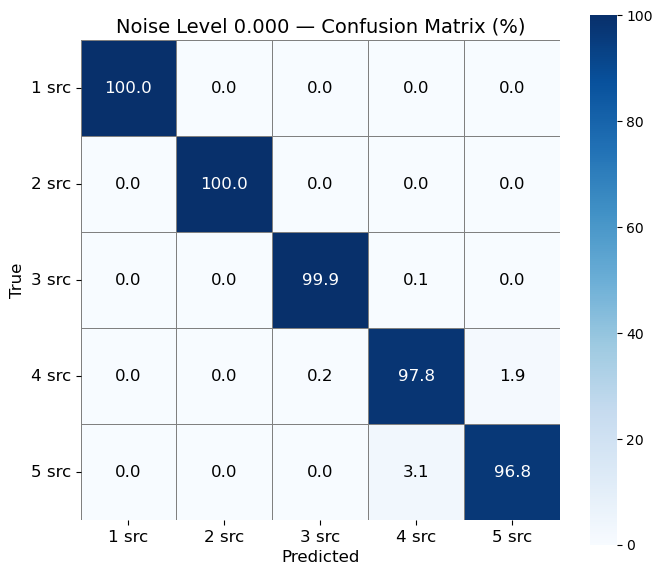

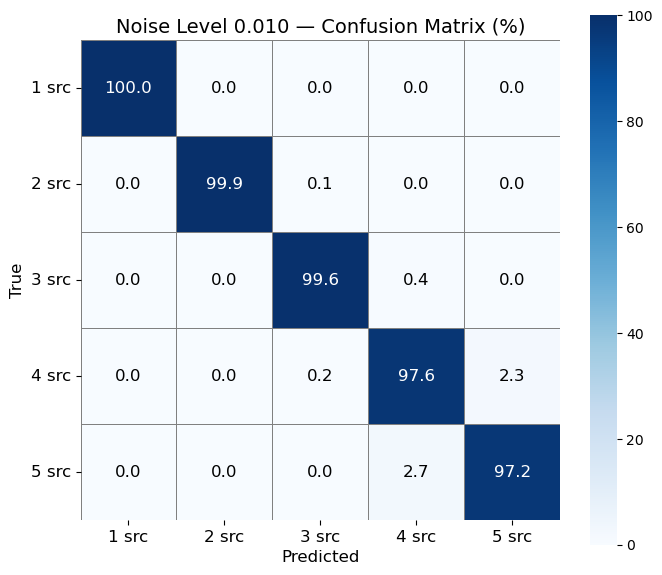

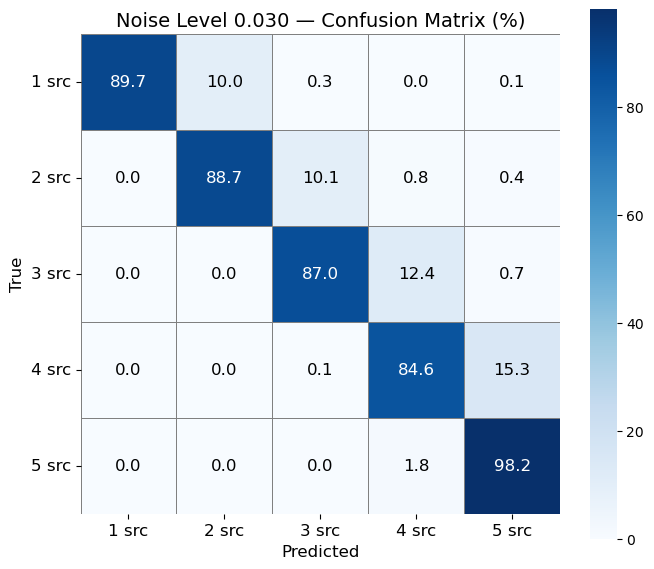

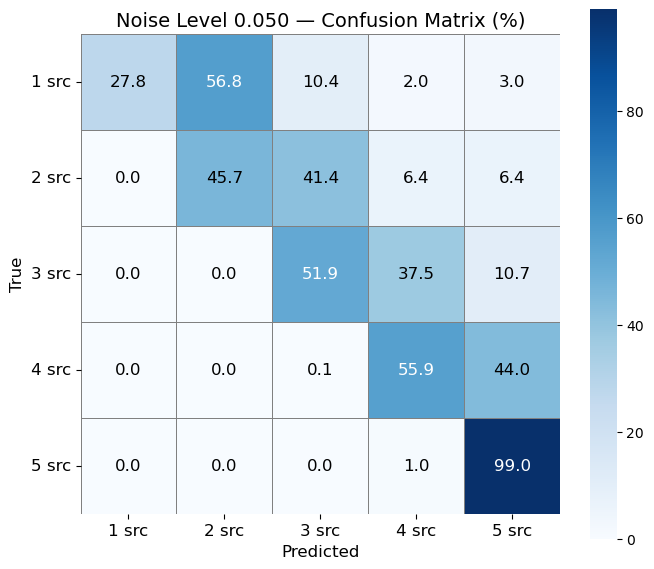

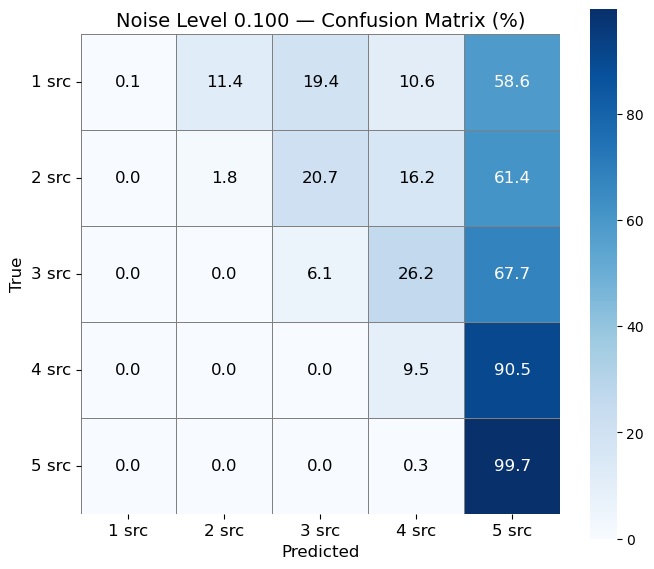

In [6]:
print("=== Noise robustness evaluation ===")

def add_noise(X, noise_level, rng=None):
    if rng is None:
        rng = np.random.default_rng(12345)
    global_std = np.std(X_train)
    noise = rng.normal(loc=0.0, scale=noise_level * global_std, size=X.shape)
    return X + noise

noise_levels = [0.00, 0.01, 0.03, 0.05, 0.10]

for nl in noise_levels:
    print(f"\n--- Noise level = {nl:.3f} ---")

    X_noisy = add_noise(X_test, nl)

    noisy_ds = TensorDataset(
        torch.from_numpy(X_noisy).to(torch.float64),
        torch.from_numpy(y_test).to(torch.long)
    )

    noisy_loader = DataLoader(noisy_ds, batch_size=64, shuffle=False)

    acc = evaluate_accuracy(model, noisy_loader, DEVICE)
    print(f"Accuracy: {acc:.6f}")

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for Xb, yb in noisy_loader:
            Xb = Xb.to(DEVICE)
            preds = model(Xb).argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(yb.numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    cm = confusion_matrix(all_targets, all_preds)

    plot_confusion_matrix_percent(
        cm,
        class_names=["1 src", "2 src", "3 src", "4 src", "5 src"],
        title=f"Noise Level {nl:.3f} — Confusion Matrix (%)"
    )
